In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import ascii
from scipy.signal import find_peaks
from matplotlib.ticker import MaxNLocator, AutoMinorLocator
from scipy.optimize import curve_fit
from astropy import constants as const
from astropy import units as u


In [2]:
#---- Velocities Corrections ----#

vel_corr_UU_For = 39e0
vel_corr_IRAS_07145 = 88e0
vel_corr_IRAS_07180 = 58e0
vel_corr_IRAS_08500 = 58e0
vel_corr_R_Hor = 38e0
vel_corr_RV_Aqr = 2e0
vel_corr_RZ_Sgr = -29.5e0
vel_corr_UU_For = -7e0
vel_corr_V510_Pup = 45e0

#Nota preguntar si aplico esto antes de transformar a velocidades o despues#


In [3]:
sources = {
    'UU_For': r"C:\Users\pablo\OneDrive\Escritorio\Trabajo con Luciano\Working folder\Carta_data\UU_For\member.uid___A001_X13d5_X139.UU_For_sci.spw22.cube.I.pbcor.fits-Z-profile-Region_1-Statistic_FluxDensity-Coordinate_Current-2026-04-05-18-31-09.tsv"}

data = {}
for name, path in sources.items():
    # loop para acceder a la data con ascii y cambiar a GHz como se trabajo en el paper
    table = ascii.read(
    path,
    names=['col1', 'col2'],   # nombres que quieras asignarle
    comment='#',                      # ignora todas las líneas con #
    delimiter='\t'                    # separador es tabulación
    )
    data[name] = table


for name, table in data.items():
    # loop para acceder a la data por nombre de source
    globals()[name] = table

## Nota Distancia en base a las coor galact5ic se pueddde establcer a que hgalaxia pertenece y talvez ahi se puede estimar una distancia
## 


MI OBJETIVO ES PODER CALCULAR EL MASS LOSS RATE DE LOS TARGETS, PARA ELLO SE USA EN EL CASO DE OPTICAMENTE DELGADO $ \Huge \dot{M} = 4.55×10^{-19}\left\lceil \frac{T_{mb}}{Log(W/0.04)s(J))}  \right\rceil ^{5/6} f_{CO}^{-1} V_{exp}^{11/6} (D\theta)^{5/3}$

Y EN EL CASO PARA OPTICAMENTE GRUESO

$\Huge  \dot{M}= 1.4 \frac{T_{mb}V_e^{2}D^{2}\theta^{2}}{2×10^{19} f_{CO}^{0.85} s(J)}$


-- UU_For --

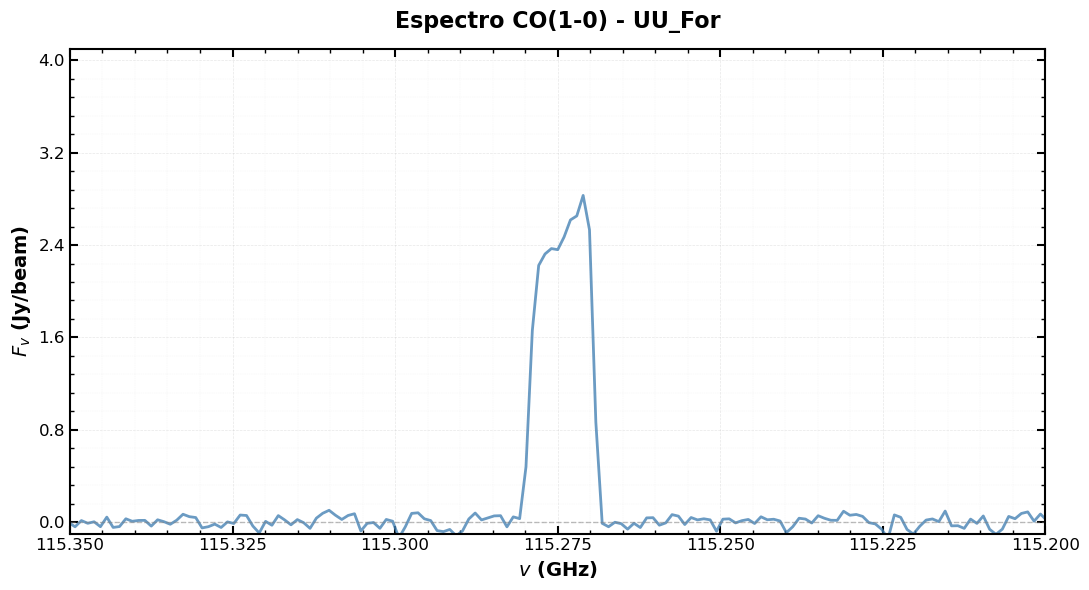

In [5]:
## Línea CO(1-0) - UU_For ##COUNT 1
lim_CO_1to0_UU_For = (115.350, 115.20)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(UU_For["col1"], UU_For["col2"], 
        linewidth=2, color='steelblue', alpha=0.8)

ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel(r'$v$ (GHz)', fontsize=14, fontweight='bold')
ax.set_ylabel(r'$F_v$ (Jy/beam)', fontsize=14, fontweight='bold')
ax.set_title('Espectro CO(1-0) - UU_For', 
             fontsize=16, fontweight='bold', pad=15)

ax.set_xlim(lim_CO_1to0_UU_For)
ax.set_ylim(-0.1, 4.1)

ax.xaxis.set_major_locator(MaxNLocator(6))
ax.yaxis.set_major_locator(MaxNLocator(6))
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.grid(True, which='major', alpha=0.3, linestyle='--', linewidth=0.5)
ax.grid(True, which='minor', alpha=0.15, linestyle='--', linewidth=0.3)

ax.tick_params(axis='both', which='major', labelsize=12, 
               direction='in', length=6, width=1.5, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', 
               length=3, width=1, top=True, right=True)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

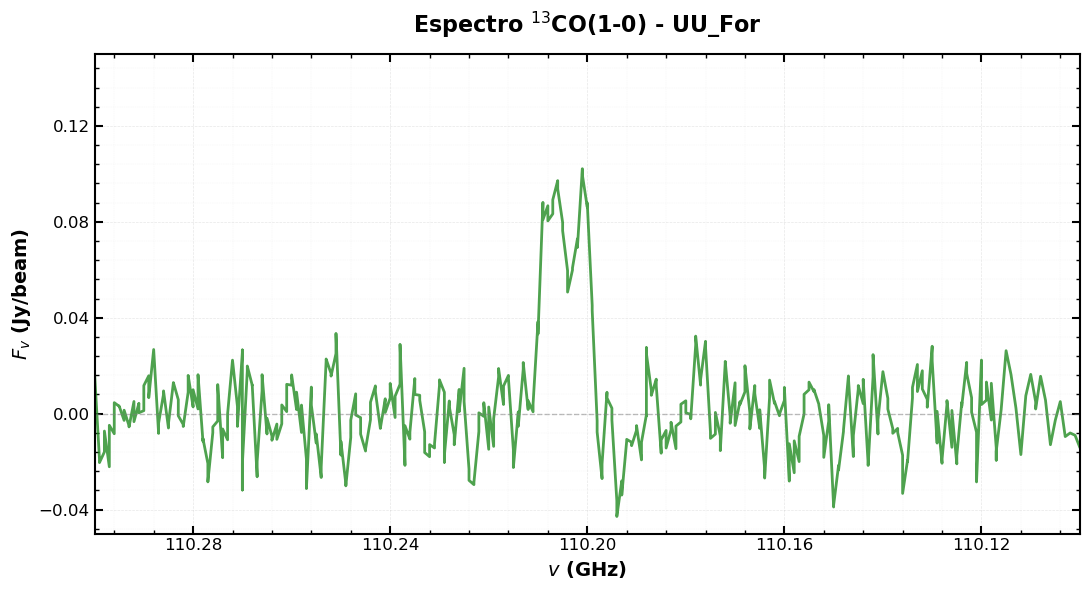

In [32]:
## Línea 13CO(1-0) - UU_For ## COUNT 1
lim_CO_2to1_UU_For = (110.30, 110.10)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(UU_For["col1"], UU_For["col2"], 
        linewidth=2, color='forestgreen', alpha=0.8)

ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.set_xlabel(r'$v$ (GHz)', fontsize=14, fontweight='bold')
ax.set_ylabel(r'$F_{v}$ (Jy/beam)', fontsize=14, fontweight='bold')

ax.set_title(r'Espectro $^{13}$CO(1-0) - UU_For', 
             fontsize=16, fontweight='bold', pad=15)

ax.set_xlim(lim_CO_2to1_UU_For)
ax.set_ylim(-0.05, 0.15)

ax.xaxis.set_major_locator(MaxNLocator(6))
ax.yaxis.set_major_locator(MaxNLocator(6))
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.grid(True, which='major', alpha=0.3, linestyle='--', linewidth=0.5)
ax.grid(True, which='minor', alpha=0.15, linestyle='--', linewidth=0.3)

ax.tick_params(axis='both', which='major', labelsize=12, 
               direction='in', length=6, width=1.5, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', 
               length=3, width=1, top=True, right=True)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

In [7]:
## NOTA: EL ISOTOPO 13CO(2-1) SE REPITE EN EL PAPER 

In [8]:
## NOTA: TAMBIEN SE REPITE EL COUNT 1 DE CO(2-1) 

PARA EL CALCULO DE $\Huge T_{mb}$ es $T_{mb}(v) = T_{mb}^{peak} \left[ 1 - \left( \frac{V -V_c}{V_e} \right)^{2} \right] , \left| V- V_c \right| < V_e$

DONDE LO PRINCIPAL ES PODER OBTENER EL VALOR DE $\Huge T_{mb}^{peak}$ con $\Huge T_{mb}^{peak}  = T_A^{\star} \frac {F_{eff}}{B_eff}$ PERO !TENGO DUDA! PUESTO QUE EL PAPER CALCULA ESTO PARA TELESCOPIO DE DISCO UNICO Y TRABAJAMOS CON UN ARRAY DE TELESCOPIOS ES POR ESTO QUE POR EL MOMENTO, CALCULO EL $\Huge T_{mb}$ CON $\Huge 1.222 × 10^3 \frac{I}{v^2 \theta_{maj} \theta_{min} } $ formula obtenida referenciando el artifulo de $Flux\: Density - Brightness\: Temperature\: Conversion\: By\: NRAO$ 

In [6]:
def find_peaks_in_range(data, x_limits, **peak_kwargs):

    x_max, x_min = x_limits 
    
    x = data["col1"]
    y = data["col2"]
    
    mask = (x >= x_min) & (x <= x_max)
    solo_true = [x for x in mask if x]
    
    indices_in_range = np.where(mask)[0]
    if len(indices_in_range) == 0:
        print(f"ERRRROR")
        return {
            'x_peaks': np.array([]),
            'y_peaks': np.array([]),
            'indices': np.array([]),
            'properties': {}
        }
    
    start_idx = indices_in_range[0]
    end_idx = indices_in_range[-1]

    peaks, properties = find_peaks(y[start_idx:end_idx+1], **peak_kwargs)
    
    peaks_original = peaks + start_idx
    
    x_peaks = x[peaks_original]
    y_peaks = y[peaks_original]
    
    return {
        'x_peaks': x_peaks,
        'y_peaks': y_peaks,
        'indices': peaks_original,
        'properties': properties
    }


#result1 = find_peaks_in_range(UU_For, lim_CO_1to0_UU_For, height=0.5, prominence=0.1) ## prueba si funciona esta funcion para encontrar peak


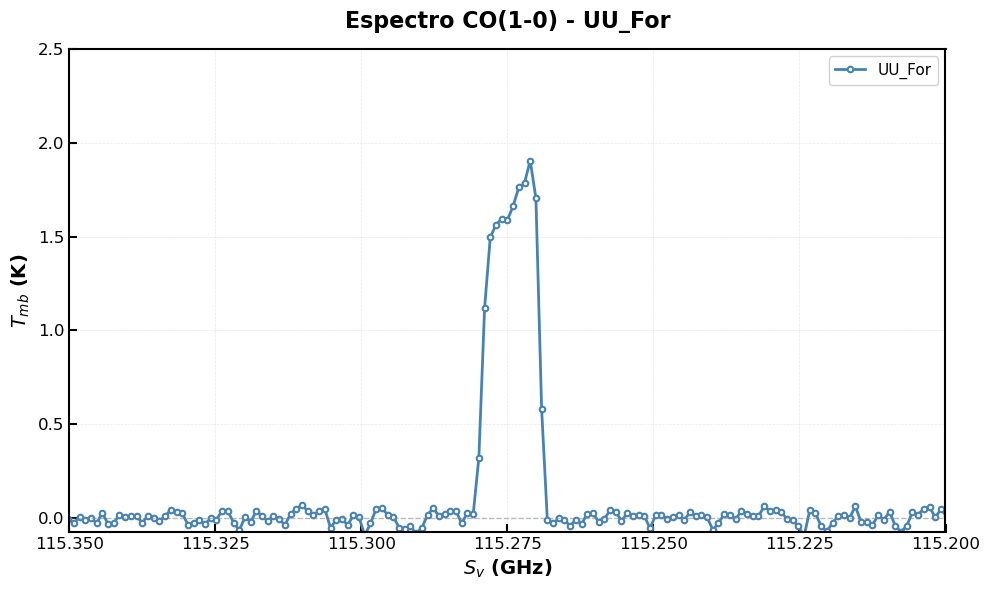

In [9]:
def convert_T_mb(data, limit):
    theta_maj =  (4.293047298298E-03) * 3600 
    theta_min =  (2.455889138257E-03) * 3600
    x_max, x_min = limit    
    x = data["col1"]
    y = data["col2"]
    
    mask = (x >= x_min) & (x <= x_max)
    indices_in_range = np.where(mask)[0]
    
    T_mb = 1.222*(10**6)*(y/
                          ((x**2) * theta_maj * theta_min))
    return {
        'col1': x, 
        'T_mb': T_mb
    }


T_mb_UU_For = convert_T_mb(UU_For, lim_CO_1to0_UU_For)


fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(T_mb_UU_For["col1"], T_mb_UU_For["T_mb"], 
        'o-', linewidth=2, markersize=4, color='steelblue', 
        markerfacecolor='white', markeredgewidth=1.5,
        label='UU_For')

ax.set_xlim(lim_CO_1to0_UU_For)

ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.set_xlabel(r'$S_v$ (GHz)', fontsize=14, fontweight='bold')
ax.set_ylabel(r'$T_{mb}$ (K)', fontsize=14, fontweight='bold')

ax.set_title('Espectro CO(1-0) - UU_For', 
             fontsize=16, fontweight='bold', pad=15)

ax.set_xlim(lim_CO_1to0_UU_For)
ax.set_ylim(-0.075, 2.5)
ax.xaxis.set_major_locator(MaxNLocator(6))
ax.yaxis.set_major_locator(MaxNLocator(6))
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.tick_params(axis='both', which='major', labelsize=12, 
               direction='in', length=6, width=1.5)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=1)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()



In [10]:
from astropy import constants as const

def freq_to_velocity(freq, freq_rest, convention='radio'):
    """
    - CO(1-0): 115.271 GHz
    - CO(2-1): 230.538 GHz
    - CO(3-2): 345.796 GHz

    """
    c = const.c.to('km/s').value  # Velocidad de la luz en km/s
    
    if convention == 'radio':
        # Definicion radio (la mas usada en radioastronomia)
        velocity = c * (freq_rest - freq) / freq_rest

    else:
        raise ValueError("Revisar eeeee")
    
    return velocity


def convert_data_to_velocity(data, freq_rest, convention='radio'):

    from copy import deepcopy
    
    data_vel = deepcopy(data)
    
    # Convertir frecuencia a velocidad
    freq_ghz = np.array(data_vel["col1"])
    velocity = freq_to_velocity(freq_ghz, freq_rest, convention)
    
    # Reemplazar col1 con velocidad
    data_vel["col1"] = velocity
    
    return data_vel


# Frecuencia de reposo de CO(1-0)
freq_rest_CO10 = 115.271  # GHz

data_vel = {}
for name, table in data.items():
    data_vel[name] = convert_data_to_velocity(table, freq_rest_CO10, convention='radio')


Parametros iniciales:
  T_peak ~ 1.905 K
  V_c    ~ -0.231 km/s
  V_e    ~ 11.429 km/s
  beta   ~ 0.40

RESULTADOS DEL AJUSTE:
T_mb^peak = 1.734 ± 0.025 K
V_c       = -7.887  ± 0.049 km/s
V_e       = 12.736  ± 0.049 km/s
R^2       = 0.9839


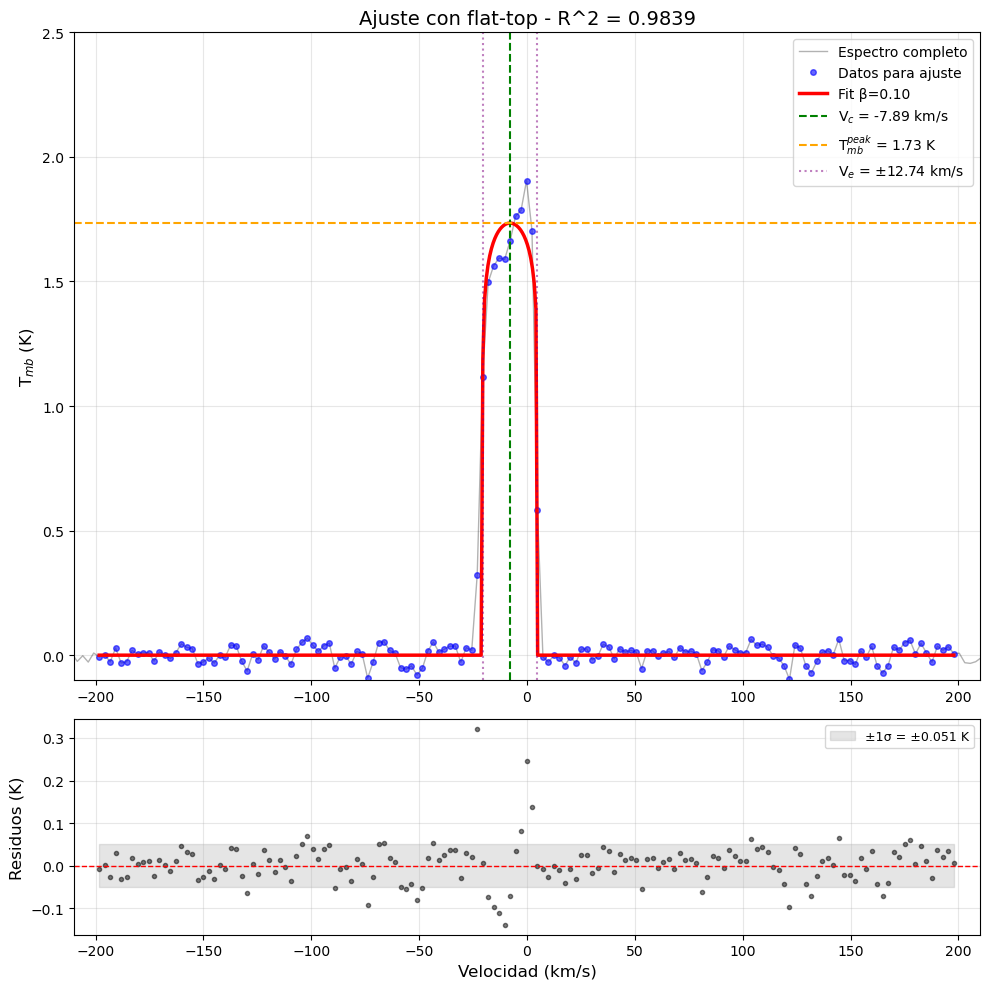

In [12]:
def flat_top_profile(v, T_peak, V_c, V_e, beta):
    
    term = ((v - V_c) / V_e)**2
    result = np.zeros_like(v, dtype=float)
    mask = term <= 1
    result[mask] = T_peak * (1 - term[mask])**beta
    return result


def fit_line_profile(data, data_1, v_limits, plot=True):

    v_min, v_max = v_limits
    
    v = np.array(data["col1"])
    T_mb_UU_For = convert_T_mb(data_1, lim_CO_1to0_UU_For)
    T_mb = T_mb_UU_For["T_mb"]
    
    mask = (v >= v_min) & (v <= v_max)
    v_fit = v[mask]
    T_fit = T_mb[mask]
    
    T_peak_guess = np.max(T_fit)
    idx_max = np.argmax(T_fit)
    V_c_guess = v_fit[idx_max]
    
    half_max = T_peak_guess / 2
    above_half = T_fit > half_max
    if np.sum(above_half) > 1:
        v_half_range = v_fit[above_half]
        V_e_guess = (v_half_range.max() - v_half_range.min()) / 2
    else:
        V_e_guess = (v_max - v_min) / 4
    
    V_e_guess = max(abs(V_e_guess), 1.0)
    beta_guess = 0.4  # <-- empieza con techo plano, la parabola clasica es 1.0
    
    p0 = [T_peak_guess, V_c_guess, V_e_guess, beta_guess]
    
    bounds = (
        [0,           v_min, 1,   0.1],   # beta minimo 0.1
        [T_peak_guess*2, v_max, (v_max-v_min), 2.0]  # beta maximo 2.0
    )
    
    print(f"Parametros iniciales:")
    print(f"  T_peak ~ {T_peak_guess:.3f} K")
    print(f"  V_c    ~ {V_c_guess:.3f} km/s")
    print(f"  V_e    ~ {V_e_guess:.3f} km/s")
    print(f"  beta   ~ {beta_guess:.2f}")
    
    try:
        popt, pcov = curve_fit(
            flat_top_profile,
            v_fit,
            T_fit,
            p0=p0,
            bounds=bounds,
            maxfev=10000
        )
        
        T_peak_fit, V_c_fit, V_e_fit, beta_fit = popt
        perr = np.sqrt(np.diag(pcov))
        
        T_model_fit = flat_top_profile(v_fit, *popt)
        residuals = T_fit - T_model_fit
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((T_fit - np.mean(T_fit))**2)
        r_squared = 1 - (ss_res / ss_tot)
        
        print(f"\n{'='*50}")
        print(f"RESULTADOS DEL AJUSTE:")
        print(f"{'='*50}")
        print(f"T_mb^peak = {T_peak_fit:.3f} ± {perr[0]:.3f} K")
        print(f"V_c       = {V_c_fit:.3f}  ± {perr[1]:.3f} km/s")
        print(f"V_e       = {V_e_fit:.3f}  ± {perr[2]:.3f} km/s")
        print(f"R^2       = {r_squared:.4f}")
        print(f"{'='*50}")
        
        if plot:
            v_model = np.linspace(v_fit.min(), v_fit.max(), 500)
            T_model = flat_top_profile(v_model, *popt)
            
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10),
                                           gridspec_kw={'height_ratios': [3, 1]})

            ax1.plot(v, T_mb, 'k-', alpha=0.3, label='Espectro completo', linewidth=1)
            ax1.plot(v_fit, T_fit, 'bo', markersize=4, label='Datos para ajuste', alpha=0.6)
            ax1.plot(v_model, T_model, 'r-', linewidth=2.5,
                     label=f'Fit β={beta_fit:.2f}')

            ax1.axvline(V_c_fit, color='green', linestyle='--', linewidth=1.5,
                        label=f'V$_c$ = {V_c_fit:.2f} km/s')
            ax1.axhline(T_peak_fit, color='orange', linestyle='--', linewidth=1.5,
                        label=f'T$_{{mb}}^{{peak}}$ = {T_peak_fit:.2f} K')
            ax1.axvline(V_c_fit - V_e_fit, color='purple', linestyle=':', alpha=0.5, linewidth=1.5)
            ax1.axvline(V_c_fit + V_e_fit, color='purple', linestyle=':', alpha=0.5, linewidth=1.5,
                        label=f'V$_e$ = ±{V_e_fit:.2f} km/s')

            ax1.set_ylabel('T$_{mb}$ (K)', fontsize=12)
            ax1.set_title(f'Ajuste con flat-top - R^2 = {r_squared:.4f}', fontsize=14)
            ax1.legend(loc='best', fontsize=10)
            ax1.grid(True, alpha=0.3)
            ax1.set_xlim([v_min - 10, v_max + 10])
            ax1.set_ylim(-0.10, 2.5)

            ax2.plot(v_fit, residuals, 'ko', markersize=3, alpha=0.5)
            ax2.axhline(0, color='red', linestyle='--', linewidth=1)
            ax2.fill_between(v_fit, -np.std(residuals), np.std(residuals),
                             alpha=0.2, color='gray',
                             label=f'±1σ = ±{np.std(residuals):.3f} K')
            ax2.set_xlabel('Velocidad (km/s)', fontsize=12)
            ax2.set_ylabel('Residuos (K)', fontsize=12)
            ax2.legend(loc='best', fontsize=9)
            ax2.grid(True, alpha=0.3)
            ax2.set_xlim([v_min - 10, v_max + 10])

            plt.tight_layout()
            plt.show()

        return {
            'T_peak': T_peak_fit,
            'V_c': V_c_fit,
            'V_e': V_e_fit,
            'beta': beta_fit,
            'errors': perr,
            'r_squared': r_squared,
            'popt': popt,
            'pcov': pcov
        }

    except Exception as e:
        print(f"ERROR en el ajuste: {e}")
        return None

v_limits = (-200, 200)  # Aaustar esto donde se vean los limites en general se puede ver en el paper jeje
T_mb_fit = fit_line_profile(data_vel['UU_For'], UU_For , v_limits, plot=True)

Siguiente paso es necesario obtener el factor $\Huge W$ se define como la relación entre el flujo emitido por tu objeto a 4.6 μm y el flujo que emitiría una estrella de referencia a la misma distancia. Aqui paso a paso para guiarse

1. Definicion de la estrella de deferencia ($\Huge F_{ref}$)Se calcula el flujo de un cuerpo negro idealizado a la misma distancia que el target.Parametros de la estrella de referencia:Radio ($\Huge R$): $\Huge 5 \times 10^{13} \text{ cm}$Temperatura ($\Huge T$): $\Huge 2000 \text{ K}$Longitud de onda ($\huge \lambda$): $\Huge 4.6 \mu m$ (Banda W2 de WISE)La fórmula del flujo observado a una distancia $d$ es:$$\Huge F_{\lambda, ref} = \frac{\pi R^2}{d^2} B_{\lambda}(T)$$Donde $\Huge B_{\lambda}(T)$ es la función de Planck:$$\Huge B_{\lambda}(T) = \frac{2hc^2}{\lambda^5} \frac{1}{e^{\frac{hc}{\lambda k_B T}} - 1}$$


3. Cálculo Final del Parámetro $\Huge W$ El ratio final se define como:$$\Huge W = \frac{F_{target}(4.6 \mu m)}{F_{ref}(4.6 \mu m, 2000 K)}$$

In [13]:
def planck_function(wavelength, T):
    
    h = const.h.cgs.value  # erg*s
    c = const.c.cgs.value  # cm/s
    k_B = const.k_B.cgs.value  # erg/K
    
    lam = wavelength * 1e-4  # um ---> cm
    
    B_lambda = (2 * h * c**2 / lam**5) / (np.exp(h * c / (lam * k_B * T)) - 1)
    
    return B_lambda


def blackbody_flux_jy(R, d_pc, T, wavelength):

    d = d_pc * const.pc.cgs.value
    
    B_lambda = planck_function(wavelength, T)
    Omega = np.pi * (R / d)**2
    
    F_lambda_cgs_per_cm = B_lambda * Omega

    lam = wavelength * 1e-4  # um ---> cm
    c = const.c.cgs.value
    
    F_nu_cgs = F_lambda_cgs_per_cm * (lam**2 / c)
    
    F_nu_jy = F_nu_cgs / 1e-23
    
    return F_nu_jy


def calculate_W_ratio(F_obs, R, d_pc, T, wavelength=4.6):

    F_BB = blackbody_flux_jy(R, d_pc, T, wavelength)
    W = F_obs / F_BB
    
    return {
        'W': W,
        'F_BB': F_BB
    }


R = 5e13  # cm
d_pc = 614.76 # parsecs
T = 2000  # K
wavelength = 4.6  # μm

# Flujo observado
#W2mag = 1.121e+02 #En el caso de que solo se tenga la magnitud
F_v0_W2 = 171.787  # Jy
F_obs = 39.2 #F_v0_W2 * 10**(-0.4 * W2mag) ##TODO: BUSCAR LA REFERENCIA DEL FLUJO

# Calcular W
result = calculate_W_ratio(F_obs, R, d_pc, T, wavelength)

print(f"\n{'='*50}")
print(f"CÁLCULO DEL RATIO W ")
print(f"{'='*50}")
print(f"Parámetros del cuerpo negro:")
print(f"  R        = {R:.2e} cm")
print(f"  d        = {d_pc:.2f} pc")
print(f"  T        = {T:.0f} K")
print(f"  λ        = {wavelength} μm")
print(f"")
print(f"Flujo observado:")
print(f"  F_obs    = {F_obs:.4f} Jy")
print(f"")
print(f"Resultados:")
print(f"  F_BB     = {result['F_BB']:.4f} Jy")
print(f"  W        = {result['W']:.4f}")
print(f"{'='*50}")


CÁLCULO DEL RATIO W 
Parámetros del cuerpo negro:
  R        = 5.00e+13 cm
  d        = 614.76 pc
  T        = 2000 K
  λ        = 4.6 μm

Flujo observado:
  F_obs    = 39.2000 Jy

Resultados:
  F_BB     = 235.8428 Jy
  W        = 0.1662


$ \Huge \dot{M} = 4.55×10^{-19}\left\lceil \frac{T_{mb}}{Log(W/0.04)s(J))}  \right\rceil ^{5/6} f_{CO}^{-1} V_{exp}^{11/6} (D\theta)^{5/3}$

In [14]:
############# Mass Loss Rate ############################
### De CO(0-1)


W = result['W'] 
T_mb_peak, V_exp = T_mb_fit["T_peak"], T_mb_fit["V_e"] # K , # km/s 
D = 614.76  # distancia pc

BMAJ_deg = 4.293047298298E-03  # grados
BMIN_deg = 2.455889138257E-03  # grados

BMAJ_arcsec = BMAJ_deg * 3600.0 # arcsec
BMIN_arcsec = BMIN_deg * 3600.0 # arcsec
theta_arcsec = np.sqrt(BMAJ_arcsec * BMIN_arcsec)  # media arcsec NOTA:preguntar si calcular la media es correcto o calculo con el FWHM

s_J   = 1.0    # factor de correccion para la transicion J ---> 0-1
f_CO  = 2e-4    # abundancia CO/H2 para UU_For NOTA: el valor fue asumido desde (Zuckerman & Dyck 1986)al igual que lo hizo (S. Ramstedt et al. 2008)


log_term  = np.log10(W / 0.04)
T_term    = T_mb_peak / (log_term * s_J)
Dtheta    = D * theta_arcsec  # pc * arcsec

### Caso de opticamnete grueso

numerador   = 1.4 * T_mb_peak * (V_exp**2) * (D**2) * (theta_arcsec**2)
denominador = 2e19 * (f_CO**0.85) * s_J

M_dot_thick = numerador / denominador

M_dot = (4.55e-19
         * (T_term ** (5/6))
         * (f_CO ** (-1))
         * (V_exp ** (11/6))
         * (Dtheta ** (5/3)))

# --- Resultados ---
print(f"\n{'='*55}")
print(f"  MASS LOSS RATE - UU_For  |  CO(1-0)")
print(f"{'='*55}")
print(f"  Parametros:")
print(f"    W              = {W:.4f}")
print(f"    log10(W/0.04)  = {log_term:.4f}")
print(f"    T_mb peak      = {T_mb_peak:.4f} K")
print(f"    V_exp          = {V_exp:.2f} km/s")
print(f"    D              = {D:.2f} pc")
print(f"    BMAJ           = {BMAJ_arcsec:.4f} arcsec")
print(f"    BMIN           = {BMIN_arcsec:.4f} arcsec")
print(f"    theta (geom.)  = {theta_arcsec:.4f} arcsec")
print(f"    D * theta      = {Dtheta:.2f} pc·arcsec")
print(f"    s(J)           = {s_J}")
print(f"    f_CO           = {f_CO:.1e}")
print(f"")
print(f"  RESULTADO:")
print(f"    Mdot = {M_dot:.4e} M_sun/yr")
print(f"    Mdot_thick = {M_dot_thick:.4e} M_sun/yr")
print(f"{'='*55}")


  MASS LOSS RATE - UU_For  |  CO(1-0)
  Parametros:
    W              = 0.1662
    log10(W/0.04)  = 0.6186
    T_mb peak      = 1.7344 K
    V_exp          = 12.74 km/s
    D              = 614.76 pc
    BMAJ           = 15.4550 arcsec
    BMIN           = 8.8412 arcsec
    theta (geom.)  = 11.6893 arcsec
    D * theta      = 7186.13 pc·arcsec
    s(J)           = 1.0
    f_CO           = 2.0e-04

  RESULTADO:
    Mdot = 1.5257e-06 M_sun/yr
    Mdot_thick = 1.4172e-06 M_sun/yr


------------------------------------------------ $\Huge  AHORA \; PARA\  CO(2-1)$ ------------------------------------------------

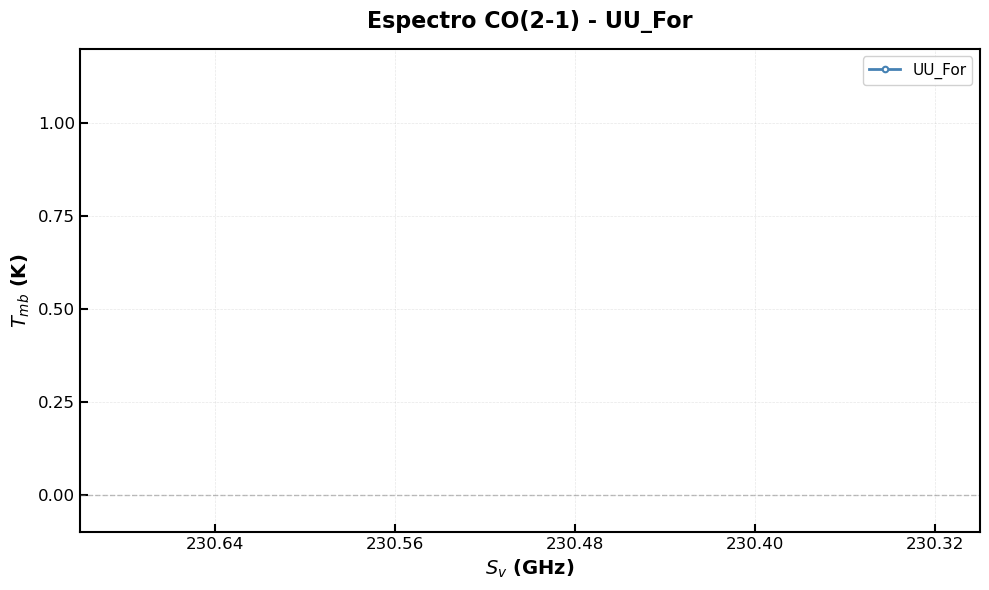

In [15]:
def convert_T_mb(data, limit):
    theta_maj = (1.809633214088E-03) * (3600)                                                 
    theta_min = (1.284642819447E-03) * (3600)
    x_max, x_min = limit    
    x = data["col1"]
    y = data["col2"]
    
    mask = (x >= x_min) & (x <= x_max)
    indices_in_range = np.where(mask)[0]
    
    T_mb = 1.222*(10**6)*(y/((x**2) * theta_maj * theta_min))
    return {
        'col1': x, 
        'T_mb': T_mb
    }


T_mb_UU_For_2to1 = convert_T_mb(UU_For, lim_CO_2to1_UU_For)


fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(T_mb_UU_For_2to1["col1"], T_mb_UU_For_2to1["T_mb"], 
        'o-', linewidth=2, markersize=4, color='steelblue', 
        markerfacecolor='white', markeredgewidth=1.5,
        label='UU_For')

ax.set_xlim(lim_CO_2to1_UU_For)

ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.set_xlabel(r'$S_v$ (GHz)', fontsize=14, fontweight='bold')
ax.set_ylabel(r'$T_{mb}$ (K)', fontsize=14, fontweight='bold')

ax.set_title('Espectro CO(2-1) - UU_For', 
             fontsize=16, fontweight='bold', pad=15)

ax.set_xlim(lim_CO_2to1_UU_For)
ax.set_ylim(-0.10, 1.2)
ax.xaxis.set_major_locator(MaxNLocator(6))
ax.yaxis.set_major_locator(MaxNLocator(6))
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.tick_params(axis='both', which='major', labelsize=12, 
               direction='in', length=6, width=1.5)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=1)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()


In [16]:
def freq_to_velocity(freq, freq_rest, convention='radio'):
    """
    - CO(1-0): 115.271 GHz
    - CO(2-1): 230.538 GHz
    - CO(3-2): 345.796 GHz

    """
    c = const.c.to('km/s').value  # Velocidad de la luz en km/s
    
    if convention == 'radio':
        # Definicion radio (la mas usada en radioastronomia)
        velocity = c * (freq_rest - freq) / freq_rest

    else:
        raise ValueError("Revisar eeeee")
    
    return velocity


def convert_data_to_velocity(data, freq_rest, convention='radio'):

    from copy import deepcopy
    
    data_vel = deepcopy(data)
    
    # Convertir frecuencia a velocidad
    freq_ghz = np.array(data_vel["col1"])
    velocity = freq_to_velocity(freq_ghz, freq_rest, convention)
    
    # Reemplazar col1 con velocidad
    data_vel["col1"] = velocity
    
    return data_vel


# Frecuencia de reposo de CO(2-1)
freq_rest_CO10 = 230.538  # GHz

data_vel_2 = {}
for name, table in data.items():
    data_vel_2[name] = convert_data_to_velocity(table, freq_rest_CO10, convention='radio')

In [17]:
def flat_top_profile(v, T_peak, V_c, V_e, beta):
    
    term = ((v - V_c) / V_e)**2
    result = np.zeros_like(v, dtype=float)
    mask = term <= 1
    result[mask] = T_peak * (1 - term[mask])**beta
    return result


def fit_line_profile(data, data_1, v_limits, plot=True):

    v_min, v_max = v_limits
    
    v = np.array(data["col1"])
    T_mb_UU_For = convert_T_mb(data_1, lim_CO_2to1_UU_For)
    T_mb = T_mb_UU_For["T_mb"]
    
    mask = (v >= v_min) & (v <= v_max)
    v_fit = v[mask]
    T_fit = T_mb[mask]
    
    T_peak_guess = np.max(T_fit)
    idx_max = np.argmax(T_fit)
    V_c_guess = v_fit[idx_max]
    
    half_max = T_peak_guess / 2
    above_half = T_fit > half_max
    if np.sum(above_half) > 1:
        v_half_range = v_fit[above_half]
        V_e_guess = (v_half_range.max() - v_half_range.min()) / 2
    else:
        V_e_guess = (v_max - v_min) / 4
    
    V_e_guess = max(abs(V_e_guess), 1.0)
    beta_guess = 0.4  # <-- empieza con techo plano, la parabola clasica es 1.0
    
    p0 = [T_peak_guess, V_c_guess, V_e_guess, beta_guess]
    
    bounds = (
        [0,           v_min, 1,   0.1],   # beta minimo 0.1
        [T_peak_guess*2, v_max, (v_max-v_min), 2.0]  # beta maximo 2.0
    )
    
    print(f"Parametros iniciales:")
    print(f"  T_peak ~ {T_peak_guess:.3f} K")
    print(f"  V_c    ~ {V_c_guess:.3f} km/s")
    print(f"  V_e    ~ {V_e_guess:.3f} km/s")
    print(f"  beta   ~ {beta_guess:.2f}")
    
    try:
        popt, pcov = curve_fit(
            flat_top_profile,
            v_fit,
            T_fit,
            p0=p0,
            bounds=bounds,
            maxfev=10000
        )
        
        T_peak_fit, V_c_fit, V_e_fit, beta_fit = popt
        perr = np.sqrt(np.diag(pcov))
        
        T_model_fit = flat_top_profile(v_fit, *popt)
        residuals = T_fit - T_model_fit
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((T_fit - np.mean(T_fit))**2)
        r_squared = 1 - (ss_res / ss_tot)
        
        print(f"\n{'='*50}")
        print(f"RESULTADOS DEL AJUSTE:")
        print(f"{'='*50}")
        print(f"T_mb^peak = {T_peak_fit:.3f} ± {perr[0]:.3f} K")
        print(f"V_c       = {V_c_fit:.3f}  ± {perr[1]:.3f} km/s")
        print(f"V_e       = {V_e_fit:.3f}  ± {perr[2]:.3f} km/s")
        print(f"R^2       = {r_squared:.4f}")
        print(f"{'='*50}")
        
        if plot:
            v_model = np.linspace(v_fit.min(), v_fit.max(), 500)
            T_model = flat_top_profile(v_model, *popt)
            
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10),
                                           gridspec_kw={'height_ratios': [3, 1]})

            ax1.plot(v, T_mb, 'k-', alpha=0.3, label='Espectro completo', linewidth=1)
            ax1.plot(v_fit, T_fit, 'bo', markersize=4, label='Datos para ajuste', alpha=0.6)
            ax1.plot(v_model, T_model, 'r-', linewidth=2.5,
                     label=f'Fit β={beta_fit:.2f}')

            ax1.axvline(V_c_fit, color='green', linestyle='--', linewidth=1.5,
                        label=f'V$_c$ = {V_c_fit:.2f} km/s')
            ax1.axhline(T_peak_fit, color='orange', linestyle='--', linewidth=1.5,
                        label=f'T$_{{mb}}^{{peak}}$ = {T_peak_fit:.2f} K')
            ax1.axvline(V_c_fit - V_e_fit, color='purple', linestyle=':', alpha=0.5, linewidth=1.5)
            ax1.axvline(V_c_fit + V_e_fit, color='purple', linestyle=':', alpha=0.5, linewidth=1.5,
                        label=f'V$_e$ = ±{V_e_fit:.2f} km/s')

            ax1.set_ylabel('T$_{mb}$ (K)', fontsize=12)
            ax1.set_title(f'Ajuste con flat-top - R^2 = {r_squared:.4f}', fontsize=14)
            ax1.legend(loc='best', fontsize=10)
            ax1.grid(True, alpha=0.3)
            ax1.set_xlim([v_min - 10, v_max + 10])
            ax1.set_ylim(-0.10, 1.5)

            ax2.plot(v_fit, residuals, 'ko', markersize=3, alpha=0.5)
            ax2.axhline(0, color='red', linestyle='--', linewidth=1)
            ax2.fill_between(v_fit, -np.std(residuals), np.std(residuals),
                             alpha=0.2, color='gray',
                             label=f'±1σ = ±{np.std(residuals):.3f} K')
            ax2.set_xlabel('Velocidad (km/s)', fontsize=12)
            ax2.set_ylabel('Residuos (K)', fontsize=12)
            ax2.legend(loc='best', fontsize=9)
            ax2.grid(True, alpha=0.3)
            ax2.set_xlim([v_min - 10, v_max + 10])

            plt.tight_layout()
            plt.show()

        return {
            'T_peak': T_peak_fit,
            'V_c': V_c_fit,
            'V_e': V_e_fit,
            'beta': beta_fit,
            'errors': perr,
            'r_squared': r_squared,
            'popt': popt,
            'pcov': pcov
        }

    except Exception as e:
        print(f"ERROR en el ajuste: {e}")
        return None

v_limits = (-200, 300)  # Aaustar esto donde se vean los limites en general se puede ver en el paper jeje
T_mb_fit_2to1 = fit_line_profile(data_vel_2['UU_For'], UU_For , v_limits, plot=True)

ValueError: zero-size array to reduction operation maximum which has no identity

In [ ]:
############# Mass Loss Rate ############################
### De CO(2-1)


W = result['W'] 
T_mb_peak, V_exp = T_mb_fit_2to1["T_peak"], T_mb_fit_2to1["V_e"] # K , # km/s 
D = 1158.35  # distancia pc

BMAJ_deg = 1.809633214088E-03 # grados
BMIN_deg = 1.284642819447E-03 # grados

BMAJ_arcsec = BMAJ_deg * 3600.0 # arcsec
BMIN_arcsec = BMIN_deg * 3600.0 # arcsec
theta_arcsec = np.sqrt(BMAJ_arcsec * BMIN_arcsec)  # media arcsec NOTA:preguntar si calcular la media es correcto o calculo con el FWHM

s_J   = 0.6    # factor de correccion para la transicion J ---> 2-1
f_CO  = 1e-3   # abundancia CO/H2 para UU_For NOTA: el valor fue asumido desde (Zuckerman & Dyck 1986)al igual que lo hizo (S. Ramstedt et al. 2008)


log_term  = np.log10(W / 0.04)
T_term    = T_mb_peak / (log_term * s_J)
Dtheta    = D * theta_arcsec  # pc * arcsec

M_dot = (4.55e-19
         * (T_term ** (5/6))
         * (f_CO ** (-1))
         * (V_exp ** (11/6))
         * (Dtheta ** (5/3)))


### Caso de opticamnete grue

numerador   = 1.4 * T_mb_peak * (V_exp**2) * (D**2) * (theta_arcsec**2)
denominador = 2e19 * (f_CO**0.85) * s_J

M_dot_thick = numerador / denominador

# --- Resultados ---
print(f"\n{'='*55}")
print(f"  MASS LOSS RATE - UU_For  |  CO(2-1)")
print(f"{'='*55}")
print(f"  Parametros:")
print(f"    W              = {W:.4f}")
print(f"    log10(W/0.04)  = {log_term:.4f}")
print(f"    T_mb peak      = {T_mb_peak:.4f} K")
print(f"    V_exp          = {V_exp:.2f} km/s")
print(f"    D              = {D:.2f} pc")
print(f"    BMAJ           = {BMAJ_arcsec:.4f} arcsec")
print(f"    BMIN           = {BMIN_arcsec:.4f} arcsec")
print(f"    theta (geom.)  = {theta_arcsec:.4f} arcsec")
print(f"    D * theta      = {Dtheta:.2f} pc·arcsec")
print(f"    s(J)           = {s_J}")
print(f"    f_CO           = {f_CO:.1e}")
print(f"")
print(f"  RESULTADO:")
print(f"    Mdot = {M_dot:.4e} M_sun/yr")
print(f"    Mdot_thick = {M_dot_thick:.4e} M_sun/yr")
print(f"{'='*55}")

$\Huge CO(2-1)$
  
Mdot = 5.5788e-07 M_sun/yr-----Mdot_thick = 1.3256e-06 M_sun/yr

$\Huge CO(1-0)$

Mdot = 5.2936e-07 M_sun/yr
------Mdot_thick = 1.2387e-06 M_sun/yr


In [ ]:
from scipy.integrate import trapezoid


T_mb_10 = T_mb_UU_For

mask_10 = (
    (T_mb_10['col1'] >= lim_CO_1to0_UU_For[1]) &
    (T_mb_10['col1'] <= lim_CO_1to0_UU_For[0])
)


freq_10 = T_mb_10['col1'][mask_10]  # GHz
vel_10  = data_vel["UU_For"][mask_10]  # km/s
vel_10 = vel_10["col1"]
T_10    = T_mb_10['T_mb'][mask_10]

sort_10 = np.argsort(vel_10)
vel_10  = vel_10[sort_10]
T_10    = np.array(T_10)[sort_10]

vel_corr = vel_corr_UU_For  
v_min_10 = vel_corr - 60   
v_max_10 = vel_corr + 60

line_mask_10 = (vel_10 >= v_min_10) & (vel_10 <= v_max_10)
I_CO10 = trapezoid(T_10[line_mask_10], vel_10[line_mask_10])

freq_rest_CO21 = 230.538  # GHz

T_mb_21 = T_mb_UU_For_2to1

mask_21 = (
    (T_mb_21['col1'] >= lim_CO_2to1_UU_For[1]) &
    (T_mb_21['col1'] <= lim_CO_2to1_UU_For[0])
)

vel_21  = data_vel_2["UU_For"]["col1"][mask_21]  # km/s
T_21    = T_mb_21['T_mb'][mask_21]

sort_21 = np.argsort(vel_21)
vel_21  = vel_21[sort_21]
T_21    = np.array(T_21)[sort_21]

v_min_21 = vel_corr - 35
v_max_21 = vel_corr + 35

line_mask_21 = (vel_21 >= v_min_21) & (vel_21 <= v_max_21)
I_CO21 = trapezoid(T_21[line_mask_21], vel_21[line_mask_21])

# --- Ratio ---
R = I_CO21 / I_CO10

# --- Interpretacion ---
if R < 0.8:
    interpretacion = "CO(1-0) sutil o ambas sutiles → opticamente DELGADO"
elif R <= 1.0:
    interpretacion = "Zona de transicion → revisar con profesor"
else:
    interpretacion = "CO(1-0) gruesa, CO(2-1) sutil o parcialmente gruesa → opticamente GRUESO"

# --- Resultados ---
print(f"\n{'='*55}")
print(f"  RATIO DE INTENSIDADES - UU_For")
print(f"{'='*55}")
print(f"  I_CO(1-0) = {I_CO10:.4f} K·km/s")
print(f"  I_CO(2-1) = {I_CO21:.4f} K·km/s")
print(f"")
print(f"  R = I_CO(2-1) / I_CO(1-0) = {R:.4f}")
print(f"")
print(f"  Interpretacion:")
print(f"  {interpretacion}")
print(f"{'='*55}")



fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Panel CO(1-0) ---
ax1 = axes[0]
ax1.plot(vel_10, T_10, 'steelblue', linewidth=1.5, alpha=0.8, label='Espectro CO(1-0)')
ax1.fill_between(vel_10[line_mask_10], T_10[line_mask_10], 
                  alpha=0.3, color='steelblue', label=f'I = {I_CO10:.2f} K·km/s')
ax1.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax1.axvline(vel_corr, color='red', linestyle=':', linewidth=1.5, alpha=0.7, label=f'V_lsr = {vel_corr} km/s')
ax1.set_xlabel('Velocidad (km/s)', fontsize=12, fontweight='bold')
ax1.set_ylabel(r'$T_{mb}$ (K)', fontsize=12, fontweight='bold')
ax1.set_title('CO(1-0) - UU_For', fontsize=13, fontweight='bold')
ax1.set_xlim(v_min_10 - 20, v_max_10 + 20)
ax1.legend(fontsize=10, framealpha=0.9)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=11, direction='in', 
                length=6, width=1.5, top=True, right=True)

# --- Panel CO(2-1) ---
ax2 = axes[1]
ax2.plot(vel_21, T_21, 'forestgreen', linewidth=1.5, alpha=0.8, label='Espectro CO(2-1)')
ax2.fill_between(vel_21[line_mask_21], T_21[line_mask_21], 
                  alpha=0.3, color='forestgreen', label=f'I = {I_CO21:.2f} K·km/s')
ax2.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.axvline(vel_corr, color='red', linestyle=':', linewidth=1.5, alpha=0.7, label=f'V_lsr = {vel_corr} km/s')
ax2.set_xlabel('Velocidad (km/s)', fontsize=12, fontweight='bold')
ax2.set_ylabel(r'$T_{mb}$ (K)', fontsize=12, fontweight='bold')
ax2.set_title('CO(2-1) - UU_For', fontsize=13, fontweight='bold')
ax2.set_xlim(v_min_21 - 20, v_max_21 + 20)
ax2.legend(fontsize=10, framealpha=0.9)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.tick_params(axis='both', which='major', labelsize=11, direction='in', 
                length=6, width=1.5, top=True, right=True)

# --- Titulo global con el ratio ---
if R < 0.8:
    color_R = 'green'
elif R <= 1.0:
    color_R = 'orange'
else:
    color_R = 'red'

fig.suptitle(f'R = I$_{{CO(2-1)}}$ / I$_{{CO(1-0)}}$ = {R:.3f}  —  {interpretacion}', 
             fontsize=12, fontweight='bold', color=color_R, y=1.02)

for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

In [ ]:
from scipy.integrate import trapezoid

# CO(1-0) 
BMAJ_CO10 = 4.972155506402E-03  # grados
BMIN_CO10 = 2.351931261700E-03  # grados

# CO(2-1) y 13CO(2-1) 
freq_rest_CO10  = 115.271  # GHz
freq_rest_CO21  = 230.538  # GHz
freq_rest_13CO21 = 220.399  # GHz

BMAJ_CO21 = 1.809633214088E-03 # grados
BMIN_CO21 = 1.284642819447E-03 # grados

BMAJ_13CO21 = BMAJ_CO10 * (freq_rest_CO10 / freq_rest_13CO21)
BMIN_13CO21 = BMIN_CO10 * (freq_rest_CO10 / freq_rest_13CO21)

def convert_T_mb(data, limit, theta_maj_deg, theta_min_deg):
    theta_maj = theta_maj_deg * 3600  # grados ---> arcsec
    theta_min = theta_min_deg * 3600  # grados ---> arcsec

    x = data["col1"]
    y = data["col2"]

    T_mb = 1.222e6 * (y / ((x**2) * theta_maj * theta_min))
    return {
        'col1': x,
        'T_mb': T_mb
    }

T_mb_10     = convert_T_mb(UU_For, lim_CO_1to0_UU_For,   BMAJ_CO10,   BMIN_CO10)
T_mb_21     = convert_T_mb(UU_For, lim_CO_2to1_UU_For,   BMAJ_CO21,   BMIN_CO21)
T_mb_13_21  = convert_T_mb(UU_For, lim_13CO_2to1_UU_For, BMAJ_13CO21, BMIN_13CO21)

mask_10 = (
    (UU_For['col1'] >= lim_CO_1to0_UU_For[1]) &
    (UU_For['col1'] <= lim_CO_1to0_UU_For[0])
)

vel_10   = np.array(data_vel['UU_For']['col1'][mask_10])
T_10     = np.array(T_mb_10['T_mb'])[mask_10]
flux_10  = np.array(UU_For['col2'][mask_10])

sort_10  = np.argsort(vel_10)
vel_10   = vel_10[sort_10]
T_10     = T_10[sort_10]
flux_10  = flux_10[sort_10]

lmask_10 = (vel_10 >= vel_corr_UU_For - 35) & (vel_10 <= vel_corr_UU_For + 35)
I_CO10       = trapezoid(T_10[lmask_10],    vel_10[lmask_10])
I_flux_CO10  = trapezoid(flux_10[lmask_10], vel_10[lmask_10])

mask_21 = (
    (UU_For['col1'] >= lim_CO_2to1_UU_For[1]) &
    (UU_For['col1'] <= lim_CO_2to1_UU_For[0])
)

vel_21   = np.array(data_vel_2['UU_For']['col1'][mask_21])
T_21     = np.array(T_mb_21['T_mb'])[mask_21]
flux_21  = np.array(UU_For['col2'][mask_21])

sort_21  = np.argsort(vel_21)
vel_21   = vel_21[sort_21]
T_21     = T_21[sort_21]
flux_21  = flux_21[sort_21]

lmask_21 = (vel_21 >= vel_corr_UU_For - 40) & (vel_21 <= vel_corr_UU_For + 40)
I_CO21       = trapezoid(T_21[lmask_21],    vel_21[lmask_21])
I_flux_CO21  = trapezoid(flux_21[lmask_21], vel_21[lmask_21])

mask_13 = (
    (UU_For['col1'] >= lim_13CO_2to1_UU_For[1]) &
    (UU_For['col1'] <= lim_13CO_2to1_UU_For[0])
)

freq_13  = np.array(UU_For['col1'][mask_13])
vel_13   = freq_to_velocity(freq_13, freq_rest_13CO21)
T_13     = np.array(T_mb_13_21['T_mb'])[mask_13]

sort_13  = np.argsort(vel_13)
vel_13   = vel_13[sort_13]
T_13     = T_13[sort_13]

lmask_13 = (vel_13 >= vel_corr_UU_For - 30) & (vel_13 <= vel_corr_UU_For + 25)
I_13CO21 = trapezoid(T_13[lmask_13], vel_13[lmask_13])

flux_13  = np.array(UU_For['col2'][mask_13])
flux_13  = flux_13[sort_13]

lmask_13_flux = (vel_13 >= vel_corr_UU_For - 30) & (vel_13 <= vel_corr_UU_For + 25)
I_flux_13CO21 = trapezoid(flux_13[lmask_13_flux], vel_13[lmask_13_flux])

R_13_vs_12_flux = I_flux_CO21 / I_flux_13CO21

R_Tmb       = I_CO21  / I_CO10
R_flux      = I_flux_CO21/I_flux_CO10
R_13_vs_12  = I_CO21/ I_13CO21


print(f"\n{'='*60}")
print(f"  RATIOS DE INTENSIDADES - UU_For")
print(f"{'='*60}")
print(f"")
print(f"  --- 12CO ---")
print(f"  I_CO(1-0) [T_mb]  = {I_CO10:.4f}  K·km/s")
print(f"  I_CO(2-1) [T_mb]  = {I_CO21:.4f}  K·km/s")
print(f"  I_CO(1-0) [Flujo] = {I_flux_CO10:.4f}  Jy/beam·km/s")
print(f"  I_CO(2-1) [Flujo] = {I_flux_CO21:.4f}  Jy/beam·km/s")
print(f"")
print(f"  R (T_mb)  = {R_Tmb:.4f}")
print(f"  R (Flujo) = {R_flux:.4f}")
print(f"")
print(f"")
print(f"  --- 13CO ---")
print(f"  I_13CO(2-1) [T_mb]  = {I_13CO21:.4f}   K·km/s")
print(f"  I_12CO(2-1) [T_mb]  = {I_CO21:.4f}   K·km/s")
print(f"  I_13CO(2-1) [Flujo] = {I_flux_13CO21:.4f}   Jy/beam·km/s")
print(f"  I_12CO(2-1) [Flujo] = {I_flux_CO21:.4f}   Jy/beam·km/s")
print(f"")
print(f"  R_13/12 (T_mb)  = {R_13_vs_12:.4f}")
print(f"  R_13/12 (Flujo) = {R_13_vs_12_flux:.4f}")
print(f"")
print(f"{'='*60}")

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

specs = [
    (axes[0], vel_10,  T_10,  lmask_10,  I_CO10,        'steelblue',   r'$^{12}$CO(1-0)'),
    (axes[1], vel_21,  T_21,  lmask_21,  I_CO21,        'forestgreen', r'$^{12}$CO(2-1)'),
    (axes[2], vel_13,  T_13,  lmask_13,  I_13CO21,      'darkorange',  r'$^{13}$CO(2-1) T_mb'),
]

for ax, vel, T, lmask, I, color, titulo in specs:
    ax.plot(vel, T, color=color, linewidth=1.5, alpha=0.8)
    ax.fill_between(vel[lmask], T[lmask], alpha=0.3, color=color,
                    label=f'I = {I:.2f}')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(vel_corr_UU_For, color='red', linestyle=':',
               linewidth=1.5, alpha=0.7, label=f'V_lsr = {vel_corr_UU_For} km/s')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Velocidad (km/s)', fontsize=11)
    ax.set_xlim(vel_corr_UU_For - 80, vel_corr_UU_For + 80)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(axis='both', which='major', labelsize=10,
                   direction='in', length=5, width=1.5, top=True, right=True)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

# ylabel correcto segun panel
axes[0].set_ylabel(r'$T_{mb}$ (K)', fontsize=11)
axes[1].set_ylabel(r'$T_{mb}$ (K)', fontsize=11)
axes[2].set_ylabel(r'$T_{mb}$ (K)', fontsize=11)

color_R = 'green' if R_Tmb < 0.8 else ('orange' if R_Tmb <= 1.0 else 'red')
fig.suptitle(
    f'R$_{{12(2-1)/(1-0)}}$ (T_mb)={R_Tmb:.3f}  |  R$_{{12(2-1)/(1-0)}}$ (Flujo)={R_flux:.3f}  |  '
    f'R$_{{13(2-1)/12(2-1)}}$ (T_mb)={R_13_vs_12:.3f}  |  R$_{{13(2-1)/12(2-1)}}$ (Flujo)={R_13_vs_12_flux:.3f}',
    fontsize=11, fontweight='bold', color=color_R, y=1.02
)

plt.tight_layout()
plt.show()

#TODO: Escoger los limites segun el rms

In [ ]:
# TODO: https://var.sron.nl/radex/radex.php ---> Comprobar con esta pagina y ver bien los parametros para poder ver la influencia